# Feature Engineering II (6/26/26)

---

*Codecademy — ML & AI Engineer Path: Feature Engineering #2. Concise grad-student notes.*

## 1) Introduction to Feature Selection Methods

**Feature selection** = choosing a *subset* of relevant, predictive features instead of throwing every available column at the model.

- **Motivation:** real datasets (e.g. patient records with hundreds of metrics) carry lots of **redundant or irrelevant** features that only add noise. More features is *not* always better.
- **Payoffs:** better accuracy & efficiency (drop variables that carry no signal), more **interpretable** results, and less time/compute to train and run.
- It's a core step in the ML pipeline — done right, it boosts predictive power *and* simplicity.

Three broad families: **filter**, **wrapper**, **embedded**.

### The three families

**Filter** — rank/filter features by a statistical criterion *before* any model is built.
- ✅ Cheap (no model fitting); ✅ model-agnostic (works for any algorithm).
- ❌ Hard to capture **multivariate** relationships (a feature weak alone may be useful *combined* with others); ❌ not tailored to a specific model.
- *Examples:* variance thresholds, correlation, mutual information.

**Wrapper** — fit a model and score it for each candidate feature *subset*; a search algorithm hunts for the best-performing combination.
- ✅ Finds the optimal set **for that specific model/problem**; ✅ accounts for multivariate relationships (performance is actually measured).
- ❌ **Expensive** — the model is re-fitted for every subset tested.
- *Examples:* forward / backward / bidirectional sequential selection, recursive feature elimination (RFE).

**Embedded** — feature selection happens *during* model training (same step as fitting).
- ✅ Model-tailored + multivariate like wrappers, but ✅ generally **cheaper** (selection is baked into the one fit).
- *Examples:* regularization (lasso / ridge), tree-based feature importance.

### At a glance

| Family | When selection happens | Uses a model? | Cost | Multivariate-aware? | Examples |
|---|---|---|---|---|---|
| **Filter** | Before modeling | No | Low | Weak | Variance threshold, correlation, mutual information |
| **Wrapper** | Around modeling (re-fit per subset) | Yes | **High** | Strong | Sequential selection (fwd/bwd/bi), RFE |
| **Embedded** | During model fitting | Yes (built in) | Medium | Strong | Lasso/Ridge, tree feature importance |

> **Rule of thumb:** start with cheap **filter** methods to prune obvious junk; reach for **wrapper/embedded** when you want a set tuned to a specific model and can afford the compute.

*Illustrative aside (not from the article): the simplest filter method — `VarianceThreshold` drops near-constant columns that carry no information.*

In [1]:
import numpy as np
from sklearn.feature_selection import VarianceThreshold

# col 0 varies, col 1 is constant (zero variance), col 2 barely varies
X_demo = np.array([[1, 5, 0.0],
                   [2, 5, 0.0],
                   [3, 5, 0.1],
                   [4, 5, 0.0]], dtype=float)

sel = VarianceThreshold(threshold=0.0)   # drop only strictly-constant features
X_kept = sel.fit_transform(X_demo)

print("per-column variance:", X_demo.var(axis=0).round(3))
print("kept columns (mask):", sel.get_support())   # -> [ True False  True]
print("shape after filter:", X_kept.shape)          # -> (4, 2): constant col 1 removed


per-column variance: [1.25  0.    0.002]
kept columns (mask): [ True False  True]
shape after filter: (4, 2)


## 2) Filter Methods (worked example)

Filter methods select features by a statistical **criterion, before** any model is built → cheap + works for any algorithm. A great **first pass** to narrow the feature pool. We'll apply three, in order, to one dataset:

1. **Variance threshold** — drop features that barely vary.
2. **Pearson's correlation** — drop redundant features & ones unrelated to the target.
3. **Mutual information** — rank features by dependence with the target (catches *non-linear* links too).

**Dataset:** 10 middle-school students. Target = `exam_score`; the other 6 columns are features. Split into features matrix `X` and target vector `y`.

In [2]:
import pandas as pd

df = pd.DataFrame(data={
    'edu_goal':    ['bachelors','bachelors','bachelors','masters','masters','masters','masters','phd','phd','phd'],
    'hours_study': [1, 2, 3, 3, 3, 4, 3, 4, 5, 5],
    'hours_TV':    [4, 3, 4, 3, 2, 3, 2, 2, 1, 1],
    'hours_sleep': [10, 10, 8, 8, 6, 6, 8, 8, 10, 10],
    'height_cm':   [155, 151, 160, 160, 156, 150, 164, 151, 158, 152],
    'grade_level': [8, 8, 8, 8, 8, 8, 8, 8, 8, 8],   # every student is an 8th grader
    'exam_score':  [71, 72, 78, 79, 85, 86, 92, 93, 99, 100],
})

X = df.drop(columns=['exam_score'])   # 10 x 6 features
y = df['exam_score']                  # 10 x 1 target
print("features:", list(X.columns))


features: ['edu_goal', 'hours_study', 'hours_TV', 'hours_sleep', 'height_cm', 'grade_level']


### Variance threshold

Drop features with **little/no variation** — they carry no information. Variance is numeric-only, so we first set aside the lone categorical column (`edu_goal`); (categoricals could be checked too, but you'd dummy-code them first).

- `VarianceThreshold(threshold=0)` (the default) drops only **zero-variance** columns; raise the threshold to allow more pruning.
- `.fit_transform()` returns a **numpy array** (loses column names) → use `.get_support(indices=True)` to recover which columns survived and re-subset the DataFrame.

In [3]:
from sklearn.feature_selection import VarianceThreshold

X_num = X.drop(columns=['edu_goal'])          # numeric features only

selector = VarianceThreshold(threshold=0)     # 0 = default: drop zero-variance cols
selector.fit_transform(X_num)

# recover surviving column names (grade_level is constant -> dropped)
num_cols = list(X_num.columns[selector.get_support(indices=True)])
print("kept numeric cols:", num_cols)         # -> hours_study, hours_TV, hours_sleep, height_cm

X_num = X_num[num_cols]
X = X[['edu_goal'] + num_cols]                 # rebuild full X, grade_level now gone
print("X after variance step:", list(X.columns))


kept numeric cols: ['hours_study', 'hours_TV', 'hours_sleep', 'height_cm']
X after variance step: ['edu_goal', 'hours_study', 'hours_TV', 'hours_sleep', 'height_cm']


### Pearson's correlation

Measures the **linear** relationship between two numeric variables: `+1` strong positive, `-1` strong negative, `0` none. Numeric-only. Two uses:

**(a) Feature–feature** — if two features are highly correlated (say |r| > 0.7) they're **redundant**; keep one. Use `df.corr()` (Pearson by default).

**(b) Feature–target** — a feature weakly correlated with the target (|r| roughly < 0.3) may not be predictive (esp. for a **linear model**). When two features are redundant, drop the one **less** correlated with the target.

Here `hours_TV` & `hours_study` are redundant (r ≈ −0.78). `hours_study` correlates more strongly with `exam_score` (r ≈ 0.905), so we drop **`hours_TV`**. `hours_sleep` & `height_cm` look uncorrelated with the target — flagged for a second look (mutual information) before dropping.

*Alternative:* `f_regression(X, y)` gives an F-statistic + p-value per feature — bigger F / smaller p = stronger correlation with the target. Same ranking as the corr matrix, sklearn-native.

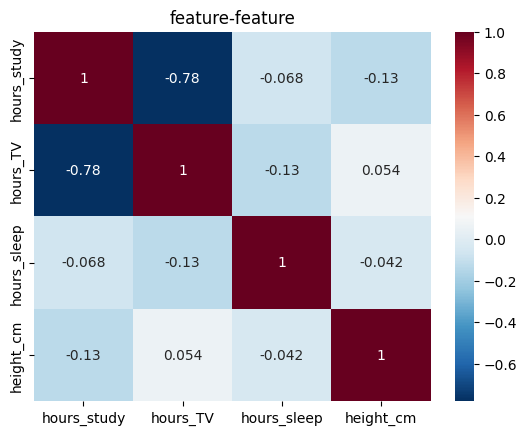

redundant pair: hours_TV & hours_study -0.781

corr with exam_score:
              exam_score
hours_study       0.905
hours_TV         -0.901
hours_sleep       0.000
height_cm         0.015

X after corr step: ['edu_goal', 'hours_study', 'hours_sleep', 'height_cm']

f_regression F: [36.14 34.45  0.    0.  ]
f_regression p: [3.000e-04 4.000e-04 1.000e+00 9.681e-01]


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import f_regression

# (a) feature-feature correlation
corr_matrix = X_num.corr(method='pearson')    # 'pearson' is default
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r'); plt.title('feature-feature'); plt.show()

# flag highly correlated pairs (lower triangle), |r| > 0.7
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            print('redundant pair:', corr_matrix.columns[i], '&', corr_matrix.columns[j],
                  round(corr_matrix.iloc[i, j], 3))   # -> hours_TV & hours_study  -0.781

# (b) feature-target correlation
X_y = X_num.copy(); X_y['exam_score'] = y
corr_target = X_y.corr()[['exam_score']].drop(labels=['exam_score'])
print('\ncorr with exam_score:\n', corr_target.round(3))

# hours_study (0.905) beats hours_TV -> drop the redundant hours_TV
X = X.drop(columns=['hours_TV'])
print('\nX after corr step:', list(X.columns))

# sklearn-native equivalent ranking: bigger F / smaller p = more correlated w/ target
F, p = f_regression(X_num, y)
print('\nf_regression F:', F.round(2))   # hours_study highest (~36.1)
print('f_regression p:', p.round(4))      # hours_study lowest p (~0.0003)


### Mutual information

**Mutual information (MI)** = how much knowing one variable reduces uncertainty about another. Like correlation but **not limited to linear** links, and it works on discrete features/targets — so it can catch associations Pearson misses. Values are ≥ 0; higher = more predictive. Categoricals must be **numerically encoded first**.

- Encode `edu_goal` with `LabelEncoder` (bachelors→0, masters→1, phd→2).
- `mutual_info_regression(X, y)` for a **continuous** target (`mutual_info_classif` for a discrete one); set `random_state` for reproducibility.
- **Tell it which columns are discrete** via `discrete_features=[...]`. `edu_goal` is discrete even after encoding — without the flag MI is mis-estimated.
- `SelectKBest(score_func=..., k=3)` keeps the top-k by score. Need extra args on the scorer (`discrete_features`, `random_state`) → wrap it with `functools.partial`.

> ⚠️ **Note:** exact MI values depend on the sklearn version (the kNN-based estimator changed), so the printed numbers here differ slightly from Codecademy's on `hours_sleep`. The **ranking and decision are identical**: `edu_goal` highest, `height_cm` = 0 MI, and `SelectKBest(k=3)` drops `height_cm`. Key insight stands — `hours_sleep` has **>0 MI but ~0 Pearson r** → a real *non-linear* link Pearson couldn't see.

In [5]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_regression, SelectKBest
from functools import partial

le = LabelEncoder()
X_enc = X.copy()
X_enc['edu_goal'] = le.fit_transform(X['edu_goal'])   # bachelors=0, masters=1, phd=2
print('cols:', list(X_enc.columns))

# WRONG: edu_goal treated as continuous
print('MI (no discrete flag):', mutual_info_regression(X_enc, y, random_state=68).round(3))
# RIGHT: edu_goal (index 0) declared discrete
print('MI (discrete=[0]):    ', mutual_info_regression(X_enc, y, discrete_features=[0], random_state=68).round(3))
# -> edu_goal highest, height_cm = 0.0 (independent of target)

# pick top-3 by MI; partial() injects the extra scorer args
score_func = partial(mutual_info_regression, discrete_features=[0], random_state=68)
selection = SelectKBest(score_func=score_func, k=3)
selection.fit_transform(X_enc, y)

X = X[X.columns[selection.get_support(indices=True)]]   # height_cm dropped
print('\nfinal selected features:', list(X.columns))     # -> edu_goal, hours_study, hours_sleep


cols: ['edu_goal', 'hours_study', 'hours_sleep', 'height_cm']
MI (no discrete flag): [0.504 0.409 0.    0.   ]
MI (discrete=[0]):     [0.756 0.389 0.119 0.   ]

final selected features: ['edu_goal', 'hours_study', 'hours_sleep']


### Recap — 6 features → 3, and why each was cut

| Feature | Verdict | Reason | Caught by |
|---|---|---|---|
| `grade_level` | ❌ dropped | zero variance (all = 8) → no info | Variance threshold |
| `hours_TV` | ❌ dropped | redundant with `hours_study` (r ≈ −0.78), weaker target corr | Pearson correlation |
| `height_cm` | ❌ dropped | ~0 correlation **and** 0 MI → independent of target | Correlation + Mutual info |
| `edu_goal` | ✅ kept | highest MI with target | Mutual info |
| `hours_study` | ✅ kept | strong linear corr (0.905) + high MI | Correlation + MI |
| `hours_sleep` | ✅ kept | ~0 Pearson but **>0 MI** → non-linear signal | Mutual info |

**Lesson:** chain cheap filters — variance → correlation → MI — and use MI to rescue features (`hours_sleep`) whose value is *non-linear* and invisible to correlation.

## 3) Wrapper Methods

**Wrapper method** = pick features by *evaluating a specific model's performance* on different feature **subsets**, adding or removing features one at a time based on how much they help that model.

**Edge over filter methods:**
- Features are judged by **actual model performance** — filters can't tell how useful a feature is *to a given model*.
- They capture **feature interactions** — a feature weak on its own may shine *combined* with others; testing subsets catches that.

(Trade-off, from §1: this costs more compute — the model is re-fit for every subset tested.)

**Five wrapper methods covered in this lesson:**
1. Sequential **forward** selection (SFS)
2. Sequential **backward** selection (SBS)
3. Sequential forward **floating** selection (SFFS)
4. Sequential backward **floating** selection (SBFS)
5. **Recursive feature elimination** (RFE)

*(Dataset for the worked examples comes next.)*

### The dataset — Breast Cancer Coimbra (UCI #451)

[Repo](https://archive.ics.uci.edu/dataset/451/breast+cancer+coimbra). Saved locally as `breast_cancer_coimbra.csv`.

- **116 patients**, **9 numeric clinical features**: `Age`, `BMI`, `Glucose`, `Insulin`, `HOMA`, `Leptin`, `Adiponectin`, `Resistin`, `MCP.1`.
- **Target `Classification`** — binary: `1` = healthy control (52), `2` = patient (64).
- Wrapper methods evaluate features *through a model*, so we need a classifier to score subsets. This lesson uses **logistic regression**.

> Reminder (from §2's leakage rule): when these selectors fit a model internally they should see only training data; here we keep the example simple but the same train/test discipline applies in practice.

In [6]:
import pandas as pd

bcc = pd.read_csv("breast_cancer_coimbra.csv")
X = bcc.drop(columns=["Classification"])   # 9 numeric features
y = bcc["Classification"]                   # 1 = healthy, 2 = patient

print("shape:", bcc.shape)
print("features:", list(X.columns))
print("class balance:", y.value_counts().to_dict())   # -> {2: 64, 1: 52}
X.head(3)

shape: (116, 10)
features: ['Age', 'BMI', 'Glucose', 'Insulin', 'HOMA', 'Leptin', 'Adiponectin', 'Resistin', 'MCP.1']
class balance: {2: 64, 1: 52}


,Age,BMI,Glucose,Insulin,HOMA,Leptin,Adiponectin,Resistin,MCP.1
0,48,23.500000,70,2.707,0.467409,8.8071,9.702400,7.99585,417.114
1,83,20.690495,92,3.115,0.706897,8.8438,5.429285,4.06405,468.786
2,82,23.124670,91,4.498,1.009651,17.9393,22.432040,9.27715,554.697


### Setting up the model — logistic regression

A wrapper method needs a model to score feature subsets, so first fit one. The lesson uses **logistic regression** on the health data.

- Split into features `X` (independent vars) and target `y` (dependent var). The article's *fire* example shows the idiom — `X = df.iloc[:, :-1]`, `y = df.iloc[:, -1]` (target = last column; see Q&A) — and we do the same on the breast-cancer data.
- **Logistic regression outputs a probability** of belonging to a class; **> 0.5 ⇒ predict patient has breast cancer**, ≤ 0.5 ⇒ healthy.
- **`.score(X, y)`** returns **accuracy** = fraction of correct predictions.

> ⚠️ Two caveats:
> 1. **Convergence:** these features span very different scales (`Glucose`~100s, `HOMA`~1), so the solver doesn't converge in the default iterations — **the lesson itself passes `max_iter=1000`** to fix it (standardizing first, per §Normalization, is the other option). The article's clean 0.984 was on its *fire* example, not this data.
> 2. **Optimistic score:** here we fit *and* score on the same `X` → that's **training** accuracy, which overstates real performance. Honest evaluation uses a held-out test set (§Train/Validation/Test).

In [7]:
from sklearn.linear_model import LogisticRegression

# X, y already built from breast_cancer_coimbra.csv above (X = iloc[:, :-1], y = iloc[:, -1])
lr = LogisticRegression(max_iter=1000)   # max_iter bumped so it converges on unscaled features
lr.fit(X, y)

print("training accuracy:", round(lr.score(X, y), 4))   # ~0.80 on this data (NOT the article's 0.984 fire example)
# this is the full-feature baseline; wrapper methods will try to match/beat it with fewer features

training accuracy: 0.8017


✅ **Exercise (lesson):** the cell above *is* the official solution — **Checkpoint 1:** `lr.fit(X, y)`; **Checkpoint 2:** `print(lr.score(X, y))`. Source uses `health = pd.read_csv("dataR2.csv")` (same file as our `breast_cancer_coimbra.csv`).

**Answer:** the model correctly predicts breast-cancer status **~80%** of the time (training accuracy ≈ 0.80) using all 9 features. That's the baseline the wrapper methods will try to match — or beat — with a smaller feature subset.

### Sequential forward selection (SFS)

**Greedy, bottom-up.** Start with **no features** and add one at a time until you hit the desired count `k`.

1. **Step 1:** train/test the model on each feature *alone*; keep the single best.
2. **Each later step:** try adding each not-yet-used feature to the current set; add whichever gives the **biggest performance gain**.
3. **Stop** once the set has `k` features.

It's **greedy** — it grabs the best *immediate* gain each step instead of brute-forcing every possible subset. Cheaper, but it can miss the globally optimal set.

**Worked example** — 5 features {`age`, `height`, `weight`, `blood_pressure`, `resting_heart_rate`}, want 3:
- Step 1 → best single feature is `{age}`.
- Step 2 tries `{age,height}`, `{age,weight}`, `{age,blood_pressure}`, `{age,resting_heart_rate}` → best `{age, resting_heart_rate}`.
- Step 3 tries `{age,height,rhr}`, `{age,weight,rhr}`, `{age,blood_pressure,rhr}` → best `{age, weight, resting_heart_rate}` → **stop** (3 features).

> **Exercise:** if we instead wanted a **4th** feature added to `{age, weight, resting_heart_rate}`, which two sets get tested next? Only the **unused** features remain: `height` and `blood_pressure`. So it tests the current set plus each of those (below).

In [8]:
# Exercise: SFS adding a 4th feature to {age, weight, resting_heart_rate}
all_features = {"age", "height", "weight", "blood_pressure", "resting_heart_rate"}
current = {"age", "weight", "resting_heart_rate"}
remaining = all_features - current          # unused features still available to add
print("remaining candidates:", remaining)   # -> {'height', 'blood_pressure'}

# Official lesson answer (explicit form) — test current set + each unused feature:
set1 = {"age", "height", "weight", "resting_heart_rate"}
set2 = {"age", "blood_pressure", "weight", "resting_heart_rate"}

# sanity check: matches "current + one remaining feature" (sets are order-independent)
assert set1 == current | {"height"}
assert set2 == current | {"blood_pressure"}
print("set1:", set1)
print("set2:", set2)

remaining candidates: {'height', 'blood_pressure'}
set1: {'resting_heart_rate', 'height', 'weight', 'age'}
set2: {'resting_heart_rate', 'weight', 'blood_pressure', 'age'}


#### Python background: the `mlxtend` SFS class

Plain sklearn doesn't do floating selection, so the lesson uses **`mlxtend`**. Its one class, `SequentialFeatureSelector` (aliased **`SFS`**), drives *any* estimator and—via flags—covers all four sequential variants. Goal here: choose a subset of **3 features** for the logistic regression model from before.

```python
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
```

**Key constructor parameters:**

| Param | Meaning | Our value |
|---|---|---|
| `estimator` | model used to score each subset | `lr` (the `LogisticRegression`) |
| `k_features` | target number of features | `3` |
| `forward` | `True` = add (forward) · `False` = remove (backward) | `True` |
| `floating` | `True` = floating (SFFS/SBFS) · `False` = plain | `False` |
| `scoring` | metric to optimize | `'accuracy'` |
| `cv` | cross-val folds; `0` = score on full set (no CV) | `0` |

**Usage:** build it, then `.fit(X, y)`. After fitting, read results off the object:
- `.subsets_` — dict of the chosen feature set **at each step** (the greedy path).
- `.k_feature_names_` — names of the final selected features.
- `.k_feature_idx_` — their column indices.
- `.k_score_` — the best score achieved.

> So `forward=True, floating=False` = **SFS**; flipping `forward`/`floating` gives SBS / SFFS / SBFS — same class, four behaviors.

#### Running SFS on the health data

The full **9-feature** model scored ~**80.2%**. Do we need all nine? If **3** features get close, the model is simpler to understand and could simplify diagnosis. So we run SFS to pick the best 3.

`forward=True, floating=False` ⇒ plain forward selection. `scoring='accuracy'` (default `None` would auto-pick a suitable metric); `cv=0` ⇒ no cross-validation, score on the training set. This page just **fits** — we read off the chosen features in the next section.

In [9]:
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

# Set up SFS to pick 3 features for our logistic regression `lr`
sfs = SFS(lr,
          k_features=3,        # select 3 features
          forward=True,        # forward selection ...
          floating=False,      # ... plain (not floating)  => SFS
          scoring='accuracy',
          cv=0)                # no cross-val; score on training set

# Fit SFS to features X and outcome y
sfs.fit(X, y)
print("SFS fitted — selected features revealed next:", sfs.k_feature_names_)

SFS fitted — selected features revealed next: ('Age', 'Glucose', 'Insulin')


✅ **Exercise (lesson):** the cell above *is* the official solution — **Checkpoint 1:** build `sfs = SFS(lr, k_features=3, forward=True, floating=False, scoring="accuracy", cv=0)`; **Checkpoint 2:** `sfs.fit(X, y)`. (Source loads `dataR2.csv` = our `breast_cancer_coimbra.csv`.)

#### Reading the SFS results

`sfs.subsets_` is a **dict keyed by feature-count** (1, 2, 3, …). Each value is itself a dict with `feature_names`, `feature_idx`, and `avg_score`. So `sfs.subsets_[3]` = the final 3-feature step:
- `sfs.subsets_[3]["feature_names"]` → the chosen features.
- `sfs.subsets_[3]["avg_score"]` → that subset's accuracy.

`plot_sfs(sfs.get_metric_dict())` plots **accuracy vs. number of features** — handy for seeing where adding features stops helping. *(Codecademy's `import codecademylib3` is just their plot-display shim; we use `plt.show()` instead.)*

chosen features: ('Age', 'Glucose', 'Insulin')
3-feature accuracy: 0.7672


/home/plewis/.local/lib/python3.10/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/plewis/.local/lib/python3.10/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


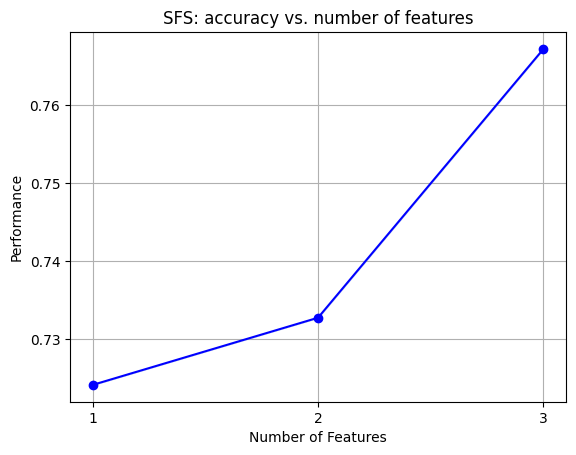

In [10]:
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs
import matplotlib.pyplot as plt

# 1) the 3 chosen feature names
print("chosen features:", sfs.subsets_[3]["feature_names"])   # -> ('Age', 'Glucose', 'Insulin')

# 2) accuracy with those 3 features
print("3-feature accuracy:", round(sfs.subsets_[3]["avg_score"], 4))   # -> ~0.7672

# 3) accuracy vs. number of features
plot_sfs(sfs.get_metric_dict())
plt.title("SFS: accuracy vs. number of features")
plt.grid(True)
plt.show()

✅ **Exercise answers:**
1. Chosen features → `('Age', 'Glucose', 'Insulin')`.
2. 3-feature accuracy → **≈ 0.767 (76.7%)**.
3. Plot: accuracy climbs Glucose → +Age → +Insulin.

**How does it compare?** The full **9-feature** model was ~**80.2%**; with just **3** features we get **76.7%** — only ~**3.5 points** lower while using **a third** of the features. A small accuracy cost for a much simpler, more interpretable model — often a worthwhile trade.

### Sequential backward selection (SBS)

The **mirror image** of SFS: start with **all** features and **remove one at a time** (the removal that hurts performance least), until you reach `k`.

**Worked example** — 5 features, want 3:
- Start with all 5; try each single removal: `{−age}`, `{−height}`, `{−weight}`, `{−blood_pressure}`, `{−rhr}`. Best is **without `blood_pressure`** → `{age, height, weight, resting_heart_rate}`.
- From those 4, try each removal → best **without `weight`** → `{age, height, resting_heart_rate}` → **stop** (3 features).

**Same `SFS` class, just `forward=False`** (`floating=False` for plain). Everything else (estimator, `k_features`, `scoring`, `cv`, the `.subsets_` API) is identical to SFS.

In [11]:
# SBS = same class as SFS, only forward=False
sbs = SFS(lr,
          k_features=3,
          forward=False,       # <-- the only change: remove features (backward)
          floating=False,
          scoring='accuracy',
          cv=0)
sbs.fit(X, y)

print("SBS chose:", sbs.subsets_[3]["feature_names"],
      "acc", round(sbs.subsets_[3]["avg_score"], 4))   # -> ('Age','Glucose','Resistin') ~0.7414

# Note: SBS landed on a DIFFERENT subset than SFS (which chose Age/Glucose/Insulin ~0.767).
# Two greedy directions explore differently -> can disagree; neither is guaranteed optimal.

SBS chose: ('Age', 'Glucose', 'Resistin') acc 0.7414


✅ **Exercise (lesson):** the cell above *is* the official solution — **Checkpoint 1:** flip `forward=False` (only change from SFS); **Checkpoint 2:** `sbs.fit(X, y)`. (Source loads `dataR2.csv` = our `breast_cancer_coimbra.csv`.)

#### Evaluating the SBS result

`sbs.subsets_` works exactly like it did for SFS — a dict with one entry per step. For **backward** selection the keys run from **all features down to `k`** (here 9 → 3). Each entry has `feature_names`, `feature_idx`, `avg_score`, `cv_scores`. `plot_sfs(sbs.get_metric_dict())` visualizes accuracy vs. number of features.

9 feat  acc=0.8017  ('Age', 'BMI', 'Glucose', 'Insulin', 'HOMA', 'Leptin', 'Adiponectin', 'Resistin', 'MCP.1')
8 feat  acc=0.8017  ('Age', 'BMI', 'Glucose', 'Insulin', 'HOMA', 'Leptin', 'Adiponectin', 'Resistin')
7 feat  acc=0.8017  ('Age', 'BMI', 'Glucose', 'Insulin', 'HOMA', 'Leptin', 'Resistin')
6 feat  acc=0.8017  ('Age', 'BMI', 'Glucose', 'Insulin', 'Leptin', 'Resistin')
5 feat  acc=0.7931  ('Age', 'BMI', 'Glucose', 'Insulin', 'Resistin')
4 feat  acc=0.7672  ('Age', 'BMI', 'Glucose', 'Resistin')
3 feat  acc=0.7414  ('Age', 'Glucose', 'Resistin')


/home/plewis/.local/lib/python3.10/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/plewis/.local/lib/python3.10/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


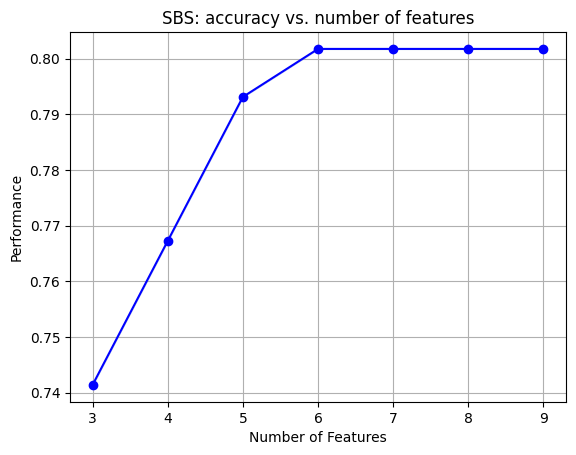

In [12]:
# sbs.subsets_ : one entry per step, keys 9 -> 3 (backward). Print the path readably:
for k in sorted(sbs.subsets_, reverse=True):
    s = sbs.subsets_[k]
    print(f"{k} feat  acc={s['avg_score']:.4f}  {s['feature_names']}")

# Plot accuracy vs. number of features
plot_sfs(sbs.get_metric_dict())
plt.title("SBS: accuracy vs. number of features")
plt.grid(True)
plt.show()

**Reading our curve:** accuracy stays flat at **0.8017 from 9 down to 6 features** — removing `MCP.1`, `Adiponectin`, and `HOMA` costs **zero** accuracy. It only drops below 6 (5→0.793, 4→0.767, 3→0.741). So **6 features match all 9** here — a free simplification. The plot flattens from 6–9 and falls off toward 3.

> Takeaway: `.subsets_` lets you pick `k` by *where the curve plateaus*, not just a number you guessed up front. (The article's *fire* example plateaus at 0.9836 from 4–6 features, same idea.)

✅ **Exercise (lesson):** the evaluation cell above covers the official solution — print `sbs.subsets_[3]["feature_names"]`, print `sbs.subsets_[3]["avg_score"]`, and `plot_sfs(sbs.get_metric_dict())`. (`codecademylib3` is just their display shim; we use `plt.show()`.)

**Exercise answers:**
1. **3 features chosen** → `('Age', 'Glucose', 'Resistin')`. **Same as SFS? No.** SFS picked `('Age', 'Glucose', 'Insulin')` — they agree on **Age** & **Glucose** but differ on the third (SBS `Resistin` vs SFS `Insulin`). Greedy from opposite ends → different answers.
2. **Accuracy** → **0.741 (74.1%)**. vs the full 9-feature model (~80.2%): ~**6 points** lower. vs **SFS** (76.7%): SBS is **slightly lower** here (~2.6 pts) — for *this* dataset/`k`, forward selection won.
3. **Reasonable trade-off?** Judgment call. 3 features is far simpler/more interpretable, and ~6 pts is a modest cost — defensible if simplicity matters. But note our own curve: **6 features already match all 9** (0.8017) for free, so if accuracy is the priority, choose `k≈6` rather than 3.

### Floating selection (SFFS / SBFS)

**Floating = a sequential method that can backtrack.**

- **SFFS (forward floating):** like SFS (add one at a time), but **after each addition, check whether *removing* a feature improves performance**. If yes, remove the best one; if no, move on and add the next. (Won't remove a feature if it would cause an infinite add/remove loop.)
- **SBFS (backward floating):** like SBS (remove one at a time), but **after each removal, check whether *adding* a feature helps**. Same loop guard.

**Why bother:** by allowing those reversals, floating tests **more subsets** and can catch feature relationships that plain SFS/SBS miss — at extra compute cost.

**mlxtend:** same `SFS` class, set **`floating=True`**. `forward=True` → SFFS; `forward=False` → SBFS.

In [13]:
# Floating on our data: same SFS class, floating=True
for name, fwd in [("SFFS", True), ("SBFS", False)]:
    sf = SFS(lr, k_features=3, forward=fwd, floating=True, scoring='accuracy', cv=0)
    sf.fit(X, y)
    print(name, "->", sf.subsets_[3]['feature_names'], "acc", round(sf.subsets_[3]['avg_score'], 4))

# Here floating lands on the SAME 3-feature sets as plain SFS/SBS:
#   SFFS == SFS  (Age, Glucose, Insulin, 0.767)
#   SBFS == SBS  (Age, Glucose, Resistin, 0.741)
# Floating CAN find better subsets by backtracking, but isn't guaranteed to differ -
# on a small problem like this the backtracking step finds nothing better to swap.

SFFS -> ('Age', 'Glucose', 'Insulin') acc 0.7672


SBFS -> ('Age', 'Glucose', 'Resistin') acc 0.7414


✅ **Exercise (lesson):** the cell above *is* the official solution — **CP1/3:** build & fit `sffs = SFS(lr, k_features=3, forward=True, floating=True, scoring="accuracy", cv=0)` and the `forward=False` `sbfs`; **CP2/4:** print `sffs.subsets_[3]["feature_names"]` and `sbfs.subsets_[3]["feature_names"]`. (Source loads `dataR2.csv` = our `breast_cancer_coimbra.csv`.)

**CP4 — are they different from the earlier algorithms?**
- **SFFS** → `('Age', 'Glucose', 'Insulin')`, 0.767 — **same as plain SFS**.
- **SBFS** → `('Age', 'Glucose', 'Resistin')`, 0.741 — **same as plain SBS**.

So on this dataset the floating backtrack found nothing better to swap: SFFS = SFS and SBFS = SBS. The two floating results still **differ from each other** on the 3rd feature (Insulin vs Resistin), exactly as forward/backward disagreed before. Floating *can* beat the plain versions on harder problems, but isn't guaranteed to here.

> **Exercise:** SBFS on `{age, height, weight, blood_pressure, resting_heart_rate}` removes `weight`, `blood_pressure`, `resting_heart_rate` (in that order) → current set `{age, height}` at **0.86**. The add-back step offers:
>
> | candidate add | accuracy |
> |---|---|
> | `{age, height, weight}` | **0.95** |
> | `{age, height, blood_pressure}` | 0.92 |
>
> Both beat the current 0.86, so it **will** add — and floating takes the **biggest** improvement → add **`weight`** (0.95 > 0.92).

In [14]:
# Exercise: floating add-back step. Current set {age, height} scores 0.86.
current_acc = 0.86
candidates = {"weight": 0.95, "blood_pressure": 0.92}   # accuracy if that feature is added

best_feat = max(candidates, key=candidates.get)
# add only if it beats the current accuracy (floating takes the biggest improvement)
added_feature = best_feat if candidates[best_feat] > current_acc else None

print("added_feature =", repr(added_feature))   # -> 'weight'  (0.95 is the biggest gain over 0.86)

added_feature = 'weight'


### Recursive feature elimination (RFE)

**Top-down, coefficient-ranked.** Train the model on **all** features, rank features by an **importance metric**, drop the **least important** one, retrain on the smaller set, re-rank, drop again — repeat until `k` features remain.

- **Ranking metric (regression):** the **absolute value of each feature's coefficient** — bigger |coef| = more important. Smallest |coef| gets eliminated.

| Feature | Coef | \|Coef\| | |
|---|---|---|---|
| resting_heart_rate | −4.6 | 4.6 | |
| weight | −4.3 | 4.3 | |
| blood_pressure | −5.7 | 5.7 | |
| height | 7.0 | 7.0 | |
| **age** | **2.5** | **2.5** | ← smallest ⇒ **removed first** |

  After dropping `age`, the model is refit on the other 4 and they're **re-ranked** (coefficients shift once `age` is gone).

- ⚠️ **Standardize first.** Coefficient size depends on feature scale, so unscaled features make |coef| a bad importance measure. In regression especially, **standardize** (§Normalization) before RFE so scale doesn't distort the ranking. *(Contrast: the sequential methods score by accuracy, so they're less scale-sensitive for ranking — though the model can still need scaling to converge.)*

**RFE vs. SBS — both go top-down, but differ in cost:**

| | Trains per step | How it decides what to drop |
|---|---|---|
| **SBS** (backward) | **one model per candidate removal** (n subsets) | drop the feature whose removal keeps accuracy **highest** |
| **RFE** | **one model total** | drop the feature with the smallest **coefficient** |

Because RFE fits just **one** model per elimination (not one per possible removal), it's **much faster** than sequential selection — its main advantage.

In [15]:
# Exercise: choose 4 of 6 features — how many subsets does each method test?

# RFE: one model per elimination. 6 -> 5 -> 4 is 2 removals = 2 subsets tested.
rfe_test_count = 2

# SBS: one model per *candidate* removal at each step.
#   6 features -> test 6 possible single-removals -> keep best (5 features)
#   5 features -> test 5 possible single-removals -> keep best (4 features)
sbs_test_count = 6 + 5          # = 11

print("RFE tests:", rfe_test_count)          # -> 2
print("SBS tests:", sbs_test_count)          # -> 11
print("fewer tests:", "RFE" if rfe_test_count < sbs_test_count else "SBS")   # -> RFE
# Takeaway: RFE trains far fewer models (2 vs 11) -> its speed advantage over sequential selection.

RFE tests: 2
SBS tests: 11
fewer tests: RFE


#### RFE with scikit-learn

RFE is built into sklearn (no mlxtend needed). Two steps:

1. **Standardize** — RFE ranks by coefficient size, so features must be on the same scale first. `StandardScaler().fit_transform(X)` returns a **numpy array** (drops column names → capture them first to label results later).
2. **`RFE(estimator, n_features_to_select=k)`** then `.fit(X, y)`. `estimator` = our `lr`; `n_features_to_select` = how many to keep.

> Reminder from §2's leakage rule: `fit_transform` the scaler on **train only** in a real pipeline; we keep it one-shot here for the demo.

In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE

# capture feature names BEFORE scaling turns X into a nameless numpy array
feature_names = list(X.columns)   # the 9 breast-cancer features

# 1) standardize so coefficient magnitudes are comparable (RFE ranks by |coef|)
X = StandardScaler().fit_transform(X)   # -> numpy array, same 116 x 9 shape

# 2) recursive feature elimination down to 3 features, using our logistic regression
#    (the lesson's demo page used 2; the exercise uses 3 -> we keep 3 so RFE is
#     comparable to SFS/SBS/floating, which all selected 3 features)
rfe = RFE(lr, n_features_to_select=3)
rfe.fit(X, y)
print("RFE fitted — kept", rfe.n_features_, "features (results read off next).")

RFE fitted — kept 3 features (results read off next).


✅ **Exercise (lesson):** the cell above *is* the official solution — **CP1:** `X = StandardScaler().fit_transform(X)`; **CP2:** `rfe = RFE(lr, n_features_to_select=3)`; **CP3:** `rfe.fit(X, y)`. (Source loads `dataR2.csv` = our `breast_cancer_coimbra.csv`, and casts `X`/`y` with `np.array(...)` — equivalent to what `StandardScaler` returns anyway.)

#### Evaluating the RFE result

Two result arrays, one entry per original feature (by column index):

- **`rfe.ranking_`** — each feature's rank. **`1` = kept**; larger numbers = *removed*, and the **largest rank was removed first**. e.g. fire data `[2 5 4 1 3 1]` → indices 3 & 5 kept (`Rain`, `FWI`); the `5` at index 1 means `RH` was dropped first, the `4` next, etc.
- **`rfe.support_`** — boolean mask, `True` = kept. e.g. `[False False False True False True]` → indices 3 & 5.

Map the mask back to names with a list comprehension over `zip(feature_names, rfe.support_)`. **`rfe.score(X, y)`** gives the kept-feature model's accuracy (delegates to the refit estimator).

In [17]:
# per-feature rank (1 = kept) and boolean keep-mask, aligned to feature_names by index
print("ranking_:", rfe.ranking_)   # -> [4 1 1 2 3 5 7 1 6]
print("support_:", rfe.support_)   # -> [F T T F F F F T F] (indices 1,2,7 kept)

# map the True/False mask back to feature names
rfe_features = [f for (f, support) in zip(feature_names, rfe.support_) if support]
print("RFE kept:", rfe_features)   # -> ['BMI', 'Glucose', 'Resistin']

# accuracy of the model on the kept features
print("RFE accuracy:", round(rfe.score(X, y), 4))   # -> 0.7328
# elimination order (highest rank removed first): Adiponectin(7) -> MCP.1(6) ->
# Leptin(5) -> Age(4) -> HOMA(3) -> Insulin(2); BMI/Glucose/Resistin (rank 1) kept.

ranking_: [4 1 1 2 3 5 7 1 6]
support_: [False  True  True False False False False  True False]
RFE kept: ['BMI', 'Glucose', 'Resistin']
RFE accuracy: 0.7328


✅ **Exercise (lesson):** the cell above *is* the official solution — **CP1:** `rfe_features = [f for (f, support) in zip(feature_list, rfe.support_) if support]` (our `feature_names` = their `feature_list`); **CP2:** `print(rfe.score(X, y))`.

**CP2 — vs the original model?** RFE with 3 features scores **0.7328 (73.3%)** vs the full **9-feature** model's ~**80.2%** — about **7 points** lower for keeping only a third of the features. In line with the other 3-feature selectors here (SFS 0.767, SBS/SBFS 0.741), and the usual wrapper trade-off: a modest accuracy cost buys a much simpler, more interpretable model. (Note RFE ran on **standardized** data, unlike the SFS/SBS runs — another reason its exact number differs.)

### Recap — the 5 wrapper methods

All five pick features by **scoring an actual model** on feature subsets (vs filters' model-free statistics), so they capture feature interactions — at higher compute cost. Two families:

| Method | Direction | Floating? | How it ranks/decides | Class |
|---|---|---|---|---|
| **SFS** | forward (add) | no | greedy: add the feature giving the best accuracy gain | `mlxtend` `SFS`, `forward=True, floating=False` |
| **SBS** | backward (remove) | no | greedy: remove the feature whose loss hurts accuracy least | `SFS`, `forward=False, floating=False` |
| **SFFS** | forward + backtrack | yes | SFS, but after each add try a remove | `SFS`, `forward=True, floating=True` |
| **SBFS** | backward + backtrack | yes | SBS, but after each remove try an add | `SFS`, `forward=False, floating=True` |
| **RFE** | backward (remove) | no | drop smallest \|coefficient\| (needs standardized data) | `sklearn` `RFE(estimator, n_features_to_select)` |

**Our 3-feature results on the breast-cancer data** (full 9-feature baseline ≈ **0.802**):

| Method | Chosen 3 features | Accuracy |
|---|---|---|
| SFS  | Age, Glucose, Insulin  | 0.767 |
| SBS  | Age, Glucose, Resistin | 0.741 |
| SFFS | Age, Glucose, Insulin *(= SFS)* | 0.767 |
| SBFS | Age, Glucose, Resistin *(= SBS)* | 0.741 |
| **RFE** | **BMI, Glucose, Resistin** | 0.733¹ |

¹ RFE ran on **standardized** data (coefficient ranking is scale-sensitive); the sequential runs did not.

**Takeaways:**
- **Only `Glucose` is chosen by every method** — the robust signal here. Beyond it the methods disagree (Insulin vs Resistin vs BMI), showing greedy searches from different directions land in different local optima; **none is guaranteed globally optimal**.
- **Floating changed nothing** on this small problem (SFFS=SFS, SBFS=SBS) — backtracking helps more on harder feature interactions.
- **RFE is the cheapest** (one model fit per elimination vs one per candidate removal for SBS) but needs **standardization**; the sequential methods score by accuracy so are less scale-sensitive for ranking.
- All three distinct subsets cost ~3–7 accuracy points vs the 9-feature model for **1/3 the features** — and SBS's curve showed **6 features already matched all 9** for free. Pick `k` where the accuracy-vs-#features curve **plateaus**, not an arbitrary number.

## Q & A

**Q: What is `fit_transform` again?**

It's `.fit()` + `.transform()` in one call.
- **`.fit(X)`** *learns* the params the operation needs and stores them on the object: `VarianceThreshold` → per-column variance; `StandardScaler` → mean & std; `MinMaxScaler` → min & max.
- **`.transform(X)`** *applies* those learned params to produce the output (drop columns, rescale, …).
- **`.fit_transform(X)`** does both at once — what you call on the **training** data.
- ⚠️ **Leakage rule:** `fit`/`fit_transform` on **train only**, then `transform` the test set with those train-derived params. Re-fitting on test leaks its statistics in.

**Q: `df.iloc`?** *(it's `df.iloc`, not `pd.iloc`)*

**Integer-location** selection — pick rows/columns by **position** (0-based), regardless of index labels. Sibling of `.loc`, which selects by **label**.
```python
df.iloc[0]          # first row
df.iloc[0, 2]       # row 0, column 2 (single value)
df.iloc[:5]         # first 5 rows (end-EXCLUSIVE, like Python slices)
df.iloc[:, 1:3]     # all rows, columns at positions 1 and 2
df.iloc[[0, 2, 4]]  # rows 0, 2, 4
```
- Positions, not labels; slicing is **end-exclusive** (`.loc` is end-*inclusive*); negative indices allowed.
- Common in feature-selection code: `X = df.iloc[:, :-1]` (all but last col), `y = df.iloc[:, -1]` (last col = target).

**Q: Can `iloc` combine rows AND columns together?**

Yes — that's the **comma**: `df.iloc[row_selector, column_selector]` selects both dimensions at once and returns their **intersection** (the sub-grid where chosen rows meet chosen columns). Each side can independently be an int, a slice, or a list.
```python
df.iloc[2, 3]               # scalar: row 2 ∩ column 3
df.iloc[0:5, 0:2]           # block: first 5 rows × first 2 columns
df.iloc[[0, 2, 4], [1, 3]]  # rows {0,2,4} × cols {1,3}  -> 3×2 grid
df.iloc[:, [0, -1]]         # ALL rows, just the first & last columns
df.iloc[10, :]              # row 10, ALL columns
```
- One selector defaults to rows: `df.iloc[3]` ≡ `df.iloc[3, :]`.

**Q: `df.iloc[:, :-1]` specifically?**

Two comma-separated selectors: **`:`** = all rows; **`:-1`** = columns from start up to **but not including** the last → every column **except the last**.
```python
X = df.iloc[:, :-1]   # all features (all but last column)
y = df.iloc[:, -1]    # target = the last column
```
- The classic features/target split **when the target is the final column**. For our dataset: `bcc.iloc[:, :-1]` ≡ `bcc.drop(columns=["Classification"])`, and `bcc.iloc[:, -1]` ≡ `bcc["Classification"]`.
- `-1` = negative index ("last"); the slice is end-**exclusive**, so `:-1` stops just before it.

**Q: Is a `LabelEncoder` similar to `fit_transform`?**

Different levels: **`fit_transform` is a *method* (the learn-then-apply pattern); `LabelEncoder` is an *estimator* that exposes it.** You call `fit_transform` *on* a `LabelEncoder` — same API as `StandardScaler`, `VarianceThreshold`, etc.
- **What it does:** maps categorical labels → integer codes `0 … n_classes−1`. `.fit` learns the mapping (unique classes, **sorted**); `.transform` applies it; `.fit_transform` both; `.inverse_transform` reverses it.
```python
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
codes = le.fit_transform(["cat", "dog", "cat", "bird"])
print(le.classes_)   # -> ['bird' 'cat' 'dog']  (sorted; index = code)
print(codes)         # -> [1 2 1 0]
```
- ⚠️ **Use it for the target `y`** (1-D only). For categorical **features `X`** use `OrdinalEncoder` (codes, multi-column) or `OneHotEncoder` (dummy columns).
- Why: integer codes imply an **order** (`bird<cat<dog`). Harmless for tree models, misleading for linear/distance-based ones → prefer one-hot there.

## TL;DR

**Feature selection** = keep a predictive *subset* of columns, not all of them → better accuracy/efficiency + interpretability. Three families:

- **Filter** — rank by a statistic *before* modeling. Cheap, model-agnostic, but weak on multivariate/interactions. *Chain them:* **variance threshold** (drop near-constant) → **Pearson correlation** (drop redundant / target-uncorrelated) → **mutual information** (catches *non-linear* links correlation misses). On the students data this cut 6 → 3 features; MI rescued `hours_sleep` (≈0 Pearson but >0 MI).
- **Wrapper** — score an *actual model* on feature subsets → captures interactions, but expensive (re-fit per subset). **Five methods**, run on breast-cancer data (baseline 9-feat LR ≈ 0.802):
  - **SFS** (forward add) → Age/Glucose/Insulin, 0.767 · **SBS** (backward remove) → Age/Glucose/Resistin, 0.741.
  - **SFFS / SBFS** = floating (`floating=True`): add/remove *with backtracking*. Same `mlxtend.SFS` class; here they matched plain SFS/SBS.
  - **RFE** (`sklearn`) → drops smallest |coef| one at a time; needs **standardized** data; only 1 fit per step (cheapest). → BMI/Glucose/Resistin, 0.733.
  - Only **Glucose** was picked by all 5; greedy searches from different directions hit different local optima → none guaranteed optimal. Use the accuracy-vs-#features **plateau** to choose `k` (SBS showed 6 feats = all 9 for free).
- **Embedded** — selection *during* fitting (lasso/ridge, tree importance): model-tailored + multivariate like wrappers but cheaper.

**Rule of thumb:** cheap **filters** to prune obvious junk → **wrapper/embedded** for a model-tuned set when you can afford the compute.

**Key APIs:** `VarianceThreshold`, `f_regression`, `mutual_info_regression`+`SelectKBest`(+`functools.partial`), `LabelEncoder`; `mlxtend` `SequentialFeatureSelector(estimator, k_features, forward, floating, scoring, cv)` → `.subsets_`/`.k_feature_names_`/`plot_sfs`; `sklearn` `StandardScaler` + `RFE(estimator, n_features_to_select)` → `.support_`/`.ranking_`/`.score`.